In [37]:
from dotenv import load_dotenv
load_dotenv()

True

In [38]:
import os
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(api_key=os.getenv("OPENAI_API_KEY"), model="gpt-4o", temperature=0)

In [39]:
# Models
from langchain.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from typing import Optional

class TranslationState(BaseModel):
    original: str = Field(..., description="The raw input from the user.")                    
    status: Optional[str] = Field(None, description="Either 'ok' for a valid translation request or 'exit' otherwise.")
    text: Optional[str] = Field(None, description="The text to translate if status is 'ok'.")
    language: Optional[str] = Field(None, description="The target language if status is 'ok'.")
    message: Optional[str] = Field(None, description="A message explaining why input is not a translation request if status is 'exit'.")
    translation: Optional[str] = Field(None, description="The translation of the provided text into the requested language.")
    xml_representation: Optional[str] = Field(None, description="The xml representation.")
    
pydantic_parser = PydanticOutputParser(pydantic_object=TranslationState)
format_instructions = pydantic_parser.get_format_instructions()

In [40]:
# Functions
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from xml.sax.saxutils import escape

def validator(state: TranslationState) -> TranslationState:
    """
    Validator node:
    Uses OpenAI to inspect the user input and determine if it requests a translation.
    It sends a prompt instructing the model to output a response in a structured format defined by our Pydantic model.
    """
    prompt = f"""
    You are a validation assistant. Analyze the following user input:
    "{state.original}"
    Determine if this is a request to translate some text. If it is, extract the text to be translated and the target language.
    {format_instructions}
    """
    
    message = HumanMessage(content=prompt)
    response = llm.invoke([message])
    reply = response.content.strip()
    
    try:
        result = pydantic_parser.parse(reply)
    except Exception as e:
        result = TranslationState(original=state.original, status="exit", message="Validation failed due to parsing error.")
    
    return result

def translator(state: TranslationState) -> TranslationState:
    """
    Translator node:
    Uses OpenAI to translate the provided text. The output is added to the Pydantic model under the "translation" key.
    """
    
    prompt = f"""
    Please translate the following text into {state.language}: "{state.text}"
    {format_instructions}
    """
    message = HumanMessage(content=prompt)
    response = llm.invoke([message])
    reply = response.content.strip()
    
    try:
        result = pydantic_parser.parse(reply)
    except Exception as e:
        result = TranslationState(original=state.original, status="exit", message="Validation failed due to parsing error.")
        
    return result

def formatter(state: TranslationState) -> TranslationState:
    """
    Formatter node:
    Formats the original request and its translation into an XML structure.
    
    Expected keys in data:
      - original: the original user input.
      - translation: the translated text.
      
    The function escapes XML special characters to ensure valid XML output.
    """

    original = escape(state.original)
    translation = escape(state.translation)
    
    xml_output = f"""<translation>
    <request>{original}</request>
    <result>{translation}</result>\n</translation>
    """
    state.xml_representation = xml_output
    return state

In [41]:
# Graph assembly
from langgraph.graph import StateGraph, START, END

graph = StateGraph(TranslationState)

graph.add_node("validator", validator)
graph.add_node("translator", translator)
graph.add_node("formatter", formatter)

graph.add_edge(START, "validator")
graph.add_conditional_edges(
    "validator",
    lambda state: state.status == "ok",
    {True: "translator", False: END}
)

graph.add_edge("translator", "formatter")
graph.add_edge("formatter", END)

app = graph.compile()

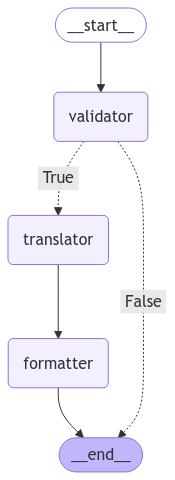

In [42]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [46]:
def run_agent():
    user_input = input("I'm a translator. How may I help you today?")
    initial_state = TranslationState(original=user_input)
    thread = {"configurable": {"thread_id": "1"}}

    for output in app.stream(initial_state, thread, stream_mode="updates"):
        print(output)
        formatter = output.get("formatter")
        if formatter is not None and formatter.get("xml_representation") is not None:
            print("===============================")
            print("-------- Final Result ---------")
            print("===============================")
            print(formatter["xml_representation"])

In [48]:
run_agent()

I'm a translator. How may I help you today? Translate "hello world" to Japanese


{'validator': {'original': 'Translate "hello world" to Japanese', 'status': 'ok', 'text': 'hello world', 'language': 'Japanese', 'message': None, 'translation': None, 'xml_representation': None}}
{'translator': {'original': 'hello world', 'status': 'ok', 'text': 'hello world', 'language': 'Japanese', 'message': None, 'translation': 'こんにちは世界', 'xml_representation': None}}
{'formatter': {'original': 'hello world', 'status': 'ok', 'text': 'hello world', 'language': 'Japanese', 'message': None, 'translation': 'こんにちは世界', 'xml_representation': '<translation>\n    <request>hello world</request>\n    <result>こんにちは世界</result>\n</translation>\n    '}}
-------- Final Result ---------
<translation>
    <request>hello world</request>
    <result>こんにちは世界</result>
</translation>
    
